In [13]:
import numpy as np
from gudhi.representations import Landscape

# Przykładowy diagram persystencji: 3 cechy topologiczne (narodziny, śmierć)
diagram = np.array([[1.0, 5.0], [2.0, 6.0], [4.0, 8.0]])

# Tworzymy obiekt krajobrazu (bierzemy 5 pierwszych warstw, próbkujemy w 100 punktach)
landscape_transformer = Landscape(num_landscapes=5, resolution=100)

# Przekształcamy diagram (Gudhi wymaga listy diagramów)
landscape_vector = landscape_transformer.fit_transform([diagram])

print(f"Rozmiar wektora krajobrazu: {landscape_vector.shape}") 
# Gotowy wektor do wrzucenia np. do algorytmu Random Forest!

Rozmiar wektora krajobrazu: (1, 500)


/tmp/ipykernel_6507/1412695642.py:14: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(pimg, cmap='hot')


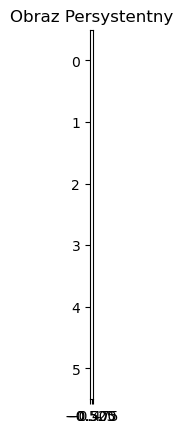

In [5]:
import numpy as np
from persim import PersistenceImager
import matplotlib.pyplot as plt

diagram = np.array([[1.0, 5.0], [2.0, 6.0], [4.0, 8.0]])

# Tworzymy "Imager" z rozdzielczością 10x10 pikseli
pimager = PersistenceImager(pixel_size=0.5)

# Generujemy obraz
pimg = pimager.fit_transform(diagram)

# pimg to teraz zwykła macierz numpy 2D!
plt.imshow(pimg, cmap='hot')
plt.title("Obraz Persystentny")
plt.show()

In [12]:
import numpy as np
from gtda.time_series import TakensEmbedding

# Udajemy, że to nasz jeden pomiar w czasie (np. prawdopodobieństwo kolejnych tokenów z LLM)
time_series = np.sin(np.linspace(0, 10, 100)) + np.random.normal(0, 0.1, 100)

# Konfigurujemy osadzenie Takensa (szukamy wektorów 3-wymiarowych, opóźnienie = 2)
embedder = TakensEmbedding(time_delay=2, dimension=3)

# Transformujemy jednowymiarowy sygnał w trójwymiarową chmurę punktów!
embedded_attractor = embedder.fit_transform(time_series.reshape(1, -1))[0]

print(f"Oryginalny sygnał: {time_series.shape}")
print(f"Odtworzony atraktor: {embedded_attractor.shape}")

Oryginalny sygnał: (100,)
Odtworzony atraktor: (96, 3)


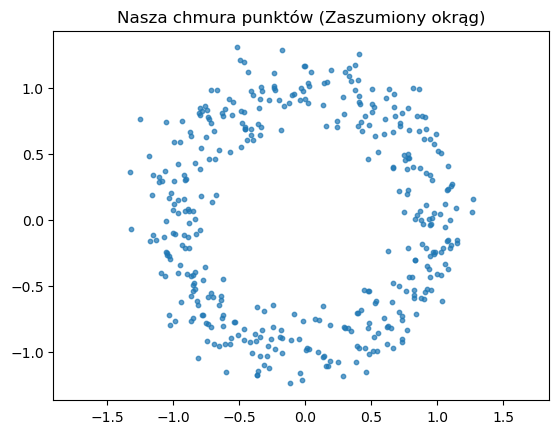

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Generujemy 400 punktów na okręgu
t = np.linspace(0, 2 * np.pi, 400)
x = np.cos(t)
y = np.sin(t)

# Dodajemy szum (model AI nigdy nie jest idealny)
szum = np.random.normal(0, 0.15, (400, 2))
dane = np.c_[x, y] + szum

# Rysujemy nasze dane, żeby zobaczyć z czym pracujemy
plt.scatter(dane[:, 0], dane[:, 1], s=10, alpha=0.7)
plt.title("Nasza chmura punktów (Zaszumiony okrąg)")
plt.axis('equal')
plt.show()

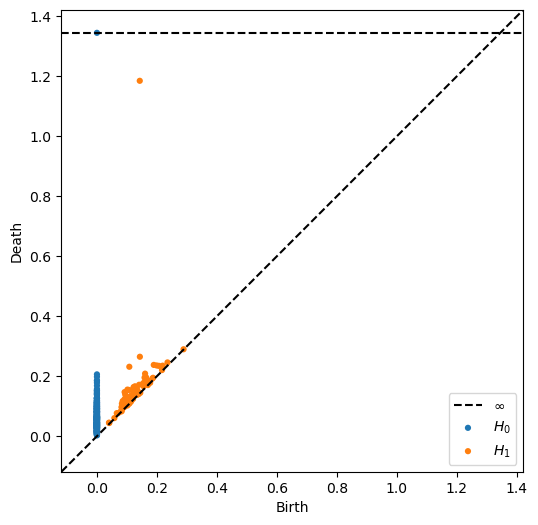

In [15]:
from ripser import ripser
from persim import plot_diagrams

# 1. Liczymy homologię! 
# maxdim=1 oznacza, że szukamy H0 (klastrów) i H1 (pętli 1D)
wynik_ripser = ripser(dane, maxdim=1)
diagramy = wynik_ripser['dgms']

# 2. Rysujemy diagram persystencji
plt.figure(figsize=(8, 6))
plot_diagrams(diagramy, show=True)

In [16]:
import kmapper as km
from sklearn.cluster import DBSCAN

# 1. Inicjujemy Mappera
mapper = km.KeplerMapper(verbose=1)

# 2. Funkcja filtrująca (Lens) - rzutujemy dane na oś X
# W AI to mogłaby być np. pierwsza składowa PCA albo odległość od środka ciężkości
lens = mapper.fit_transform(dane, projection=[0])

# 3. Definiujemy pokrycie (Koszyki) i Klastrowanie
# 15 koszyków z 30% nałożeniem na siebie
pokrycie = km.Cover(n_cubes=15, perc_overlap=0.3)
klasteryzator = DBSCAN(eps=0.2, min_samples=3)

# 4. Budujemy graf topologiczny
graf = mapper.map(lens, dane, cover=pokrycie, clusterer=klasteryzator)

# 5. Generujemy piękny, interaktywny plik HTML!
mapper.visualize(graf, path_html="moj_pierwszy_mapper.html", title="Graf szumiącego okręgu")
print("Gotowe! Otwórz plik 'moj_pierwszy_mapper.html' w swojej przeglądarce.")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x73dde9ca4ea0>
Traceback (most recent call last):
  File "/home/bamichal/miniforge3/envs/tda_stable/lib/python3.11/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/bamichal/miniforge3/envs/tda_stable/lib/python3.11/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/home/bamichal/miniforge3/envs/tda_stable/lib/python3.11/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bamichal/miniforge3/envs/tda_stable/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
  

KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: [0]
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (400, 2)

..Projecting data using: [0]

..Scaling with: MinMaxScaler()

Mapping on data shaped (400, 2) using lens shaped (400, 1)

Creating 15 hypercubes.

Created 29 edges and 29 nodes in 0:00:00.036560.
Wrote visualization to: moj_pierwszy_mapper.html
Gotowe! Otwórz plik 'moj_pierwszy_mapper.html' w swojej przeglądarce.


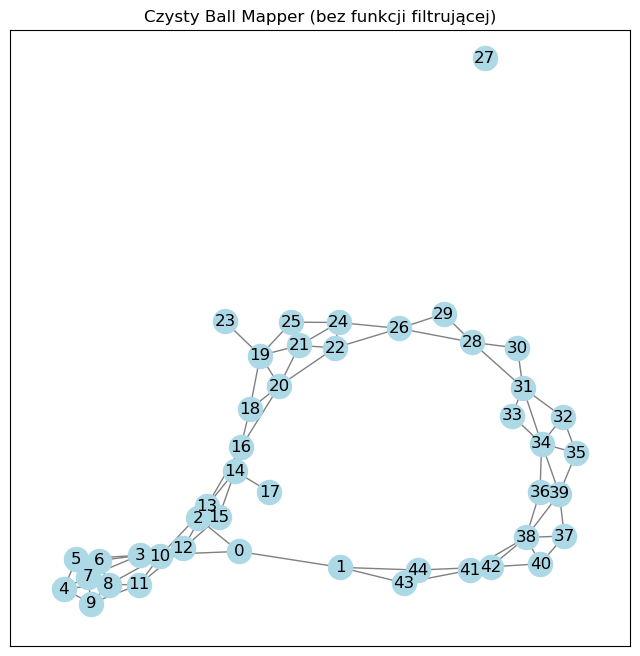

In [19]:
from pyballmapper import BallMapper
import networkx as nx

# Budujemy Ball Mappera w oparciu o promień kuli epsilon = 0.25
bm = BallMapper(X=dane, eps=0.25)

# PyBallMapper domyślnie używa biblioteki NetworkX do struktury grafu
# i potrafi go wyrysować na płaszczyźnie za pomocą matplotlib
plt.figure(figsize=(8, 8))
nx.draw_networkx(bm.Graph, pos=nx.spring_layout(bm.Graph, seed=42), 
                 node_color='lightblue', edge_color='gray')
plt.title("Czysty Ball Mapper (bez funkcji filtrującej)")
plt.show()

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MinimalnyVAE(nn.Module):
    def __init__(self):
        super().__init__()
        # ENKODER: Kompresuje obrazek do ukrytych cech
        self.enkoder = nn.Linear(784, 400) 
        
        # Zamiast jednego wektora, VAE wypluwa DWA wektory:
        self.fc_mu = nn.Linear(400, 20)      # Średnie (mu)
        self.fc_logvar = nn.Linear(400, 20)  # Wariancje (log_var)
        
        # DEKODER: Odtwarza obrazek
        self.dekoder = nn.Linear(20, 784)

    def reparameterize(self, mu, logvar):
        # TO JEST MAGIA VAE: Losujemy punkt z rozkładu normalnego!
        std = torch.exp(0.5 * logvar) # Odchylenie standardowe
        eps = torch.randn_like(std)   # Szum z N(0,1)
        return mu + eps * std         # Przesuwamy i skalujemy szum

    def forward(self, x):
        h1 = F.relu(self.enkoder(x))
        mu, logvar = self.fc_mu(h1), self.fc_logvar(h1)
        
        # Ograniczamy przestrzeń do rozmytej strefy
        z = self.reparameterize(mu, logvar) 
        
        return self.dekoder(z), mu, logvar

# JAK VAE JEST KARANY MATEMATYCZNIE? (Loss function)
def vae_loss(zrekonstruowane_x, oryginalne_x, mu, logvar):
    BCE = F.mse_loss(zrekonstruowane_x, oryginalne_x) # Błąd odtworzenia
    
    # DYWERGENCJA KULLBACKA-LEIBLERA (KL Divergence)
    # To ta część zmusza model, żeby wszystkie klastry ułożyły się 
    # w jeden wielki rozkład Gaussa (b_0 = 1).
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

In [22]:
from transformers import AutoTokenizer, AutoModel
import torch

# 1. Pobieramy gotowego BERT-a z internetu
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

# 2. Nasze dane wejściowe
zdanie = "Topology and Artificial Intelligence make a great combination."

# 3. Tniemy tekst na tokeny (matematyczne fragmenty słów)
tokeny = tokenizer(zdanie, return_tensors="pt")

# 4. PRZEPUSZCZAMY PRZEZ MODEL (Wyłączamy liczenie gradientów, bo nie trenujemy)
with torch.no_grad():
    wynik = model(**tokeny)

# 5. WYCIĄGAMY PRZESTRZEŃ UKRYTĄ (Latent Space)
# To jest ta słynna przestrzeń wysokowymiarowa!
przestrzen_ukryta = wynik.last_hidden_state 

# Wyciągamy to z formatu PyTorch do zwykłego numpy (żeby dać to Mapperowi)
wektory_numpy = przestrzen_ukryta.squeeze().numpy()

print(f"Kształt macierzy BERT: {wektory_numpy.shape}")
# Wynik to np. (10, 768). Oznacza to 10 tokenów, gdzie każdy 
# jest punktem w 768-wymiarowej przestrzeni!

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Kształt macierzy BERT: (11, 768)


In [23]:
# Szkielet pojedynczego bloku LLM-a
class BlokLLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.uwaga = nn.MultiheadAttention(embed_dim=768, num_heads=12)
        
        # TO JEST FEED-FORWARD (FFN)
        # Zauważ, że tymczasowo rozszerza wymiar z 768 do aż 3072!
        # Tu model przechowuje swoją "wiedzę o świecie".
        self.feed_forward = nn.Sequential(
            nn.Linear(768, 3072),
            nn.GELU(), # Nieliniowość
            nn.Linear(3072, 768) # Powrót do 768
        )

    def forward(self, x):
        # 1. Tokeny wymieniają się informacjami (Attention)
        x_po_uwadze, _ = self.uwaga(x, x, x)
        
        # 2. Każdy token z osobna przechodzi przez FFN
        x_wyjscie = self.feed_forward(x_po_uwadze)
        return x_wyjscie